# Lab: Simple Linear Regression
*In this lab, we will build a Simple Linear Regression model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stage 1: Business Understanding
The goal of this stage is to fully understand the project from a **business perspective**. This involves clarifying the business context, identifying the specific problem to be solved, and defining clear project goals that align with business objectives.

> #### 📝 Business Understanding Report (Summary)
> * **Business Context:**  This project simulates a common business problem for a hypothetical company, "AdSmart." The company allocates its budget across TV, Radio, and Newspaper advertising but lacks a data-driven way to understand the impact of this spending on sales.
> *   **Business Problem:** The marketing team cannot confidently predict how changes in advertising spend will affect sales, making budget allocation inefficient and based on intuition rather than evidence.
> *   **Project Goal:** To build a predictive model that quantifies the relationship between advertising spend and sales. This initial lab will focus on *creating a simple model to analyze the impact of TV advertising on Sales*, proving the concept and providing an initial actionable insight.

---

## Stage 2: Analytic Approach
The goal of this stage is to reframe the business problem defined in the previous stage into a formal **data science and machine learning framework**. This involves selecting the type of problem, proposing candidate algorithms, and defining the technical success metrics for evaluation.

> #### 📝 Analytic Approach Report (Summary)
> *   **Problem Type:** *Supervised Regression*, as the goal is to predict a continuous numerical value (Sales).
> *   **Model Selection:** We will use *Simple Linear Regression* as our baseline model. Its simplicity and high interpretability are ideal for establishing the fundamental relationship between a single feature (TV ad spend) and the target (Sales).
> *   **Evaluation Metrics:**
>     *   **R-squared:** To measure how much of the variability in sales our model can explain.
>     *   **Regression Coefficient:** To provide a direct, actionable insight into how each dollar spent on TV advertising impacts sales units.

---

## Stage 3: Data Requirements
The goal of this stage is to create a detailed specification of all the data needed to execute the analytic approach defined in the previous stage. This involves translating the proposed models and features into a concrete list of required data fields, formats, sources, and entities. This plan ensures that the data collection process is targeted and efficient. 

> #### 📝 Data Requirements Report (Summary)
> *   **Data Source:** The `advertising.csv` dataset, which contains data from 200 different markets.
> *   **Key Fields:**
>    *   **Feature (Independent Variable):** `TV` (spend in thousands of dollars).
>    *   **Target (Dependent Variable):** `Sales` (in thousands of units).
> *   **Granularity & Privacy:** Each row represents an individual market. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection
The goal of this stage is to gather the data specified in the **Data Requirements** stage. In a real-world project, this often involves writing and executing scripts to query databases, access APIs, or process raw files, and then consolidating the raw data into an accessible location for the project.

However, for this lab, the data collection step is simplified as the dataset is already provided and saved to `./data/advertising.csv`.

### 4.1. Initial Data Ingestion and Verification
Let's import the necessary libraries, load the dataset, and perform a quick, high-level check to ensure it is readable and appears correct.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the data (TV and Sales columns only)
data = pd.read_csv("./data/advertising.csv")

# Take a look at the first 5 rows
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Display general information about the data
data.info()
print("_" * 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
________________________________________


> #### 📝 Data Collection Report (Summary)
> * The provided data was saved to and successfully loaded from `./data/advertising.csv`.
> * The number of rows matches the expected count of 200 markets. The `Unnamed: 0` column appears to be an index and can be dropped. The other columns (`TV`, `Radio`, `Newspaper`, `Sales`) are present as expected.
> * **Conclusion:** No immediate issues were detected during the initial verification, allowing us to proceed to the next stage.

---

## Stage 5: Data Understanding

The goal of this stage is to conduct Exploratory Data Analysis (EDA) to develop a deep understanding of the data's content, quality, and structure. Through descriptive statistics and visualization, we aim to uncover initial patterns, spot anomalies or data quality issues, and validate (or challenge) the initial hypotheses formed during the business understanding phase.

### 5.1. Initial Data Shaping

Before diving into analysis, let's perform a first pass of cleaning and shaping to handle obvious errors and inconsistencies that would otherwise break visualizations or skew summary statistics.

In [4]:

# Drop columns we know we won't be using
sales_df = data.drop(columns=['Unnamed: 0', 'Radio', 'Newspaper'])

# Convert column names to lower case
sales_df.columns = [col.lower() for col in sales_df.columns]

# Check the number of duplicated rows
print(f"There are {sales_df.duplicated().sum()} duplicated rows in the dataset.")

There are 0 duplicated rows in the dataset.


In [5]:
# Check the data types of the columns
print(sales_df.dtypes)

tv       float64
sales    float64
dtype: object


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

In [6]:
sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
tv,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


### 5.3. Univariate Analysis
Now, let's analyze individual variables to understand their own distributions and characteristics.

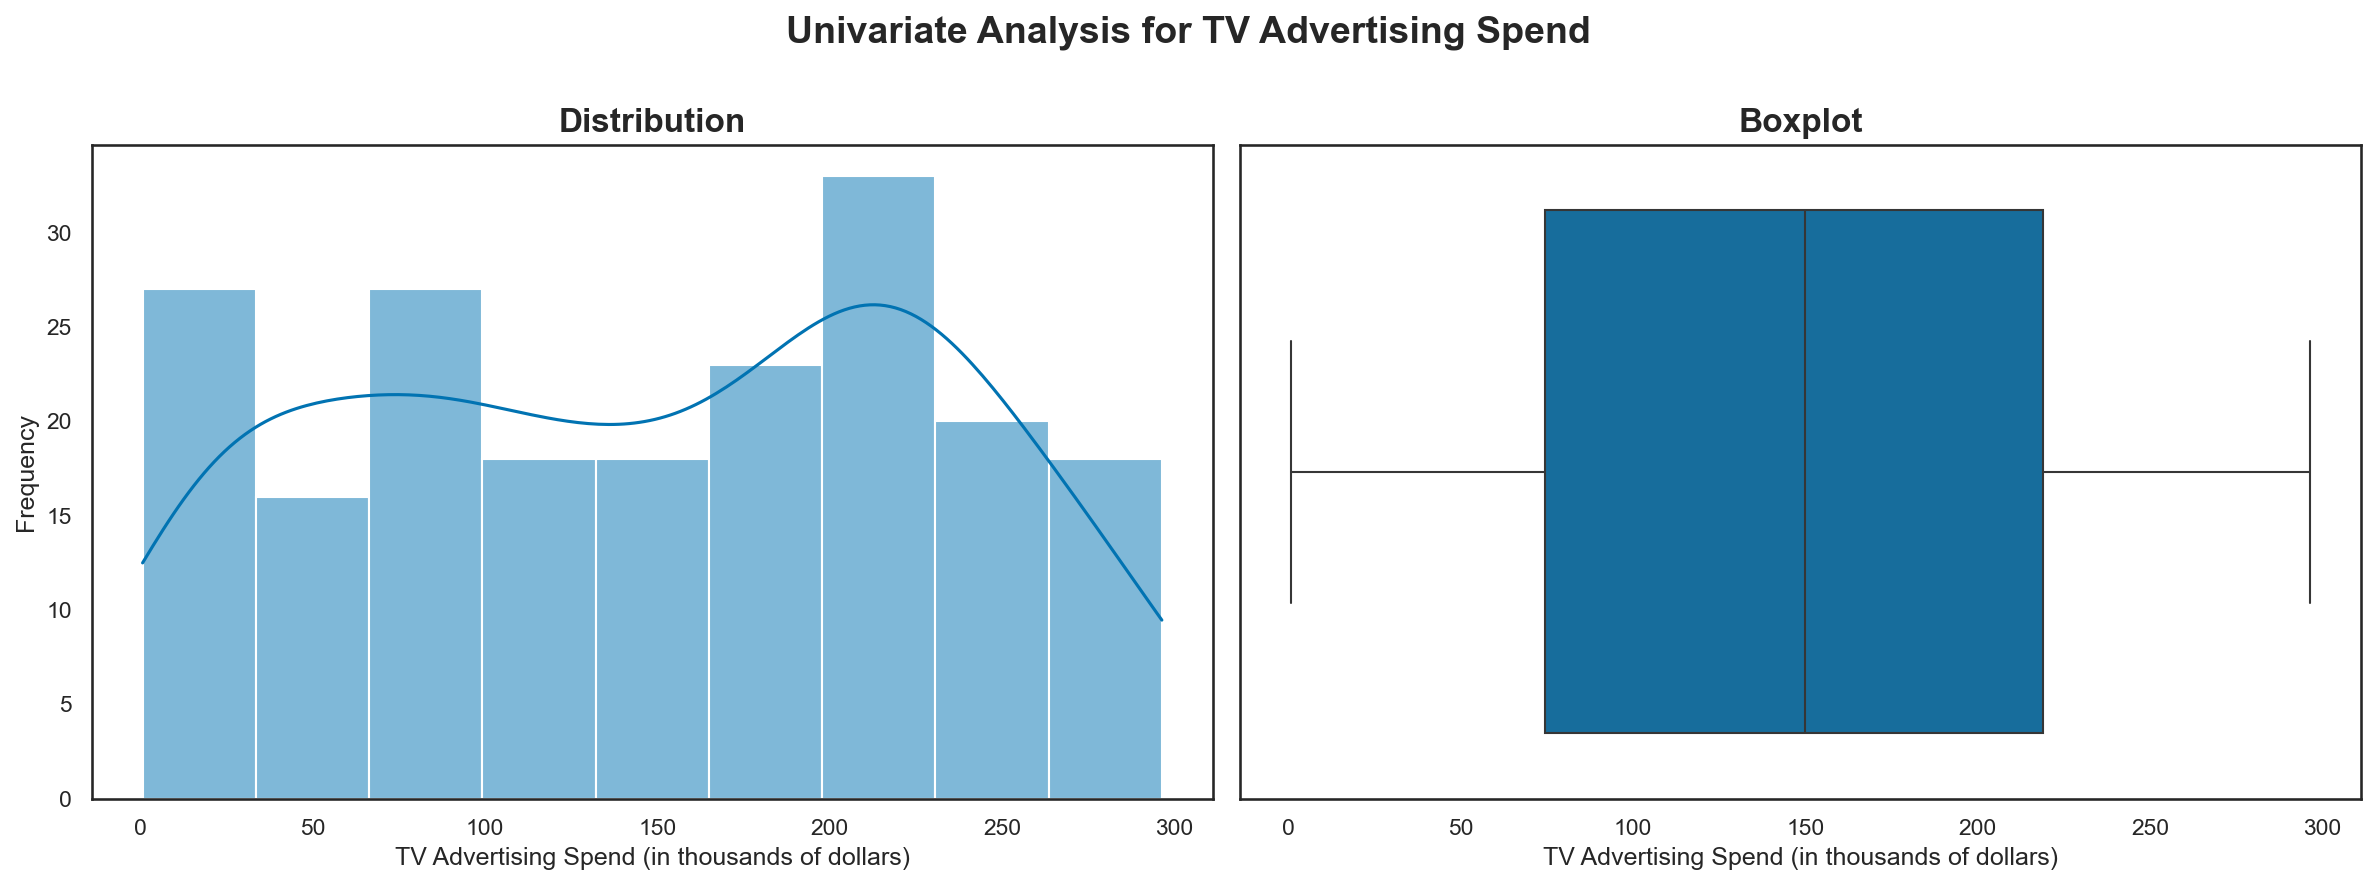

In [7]:
# Univariate Analysis for TV Advertising Spend
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for TV Advertising Spend", fontsize=18, fontweight='bold')

# The histogram of TV advertising spend
sns.histplot(sales_df, x="tv", kde=True, ax=ax[0])
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("TV Advertising Spend (in thousands of dollars)")
ax[0].set_ylabel("Frequency")

# The boxplot of TV advertising spend
sns.boxplot(sales_df, x="tv", ax=ax[1])
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("TV Advertising Spend (in thousands of dollars)")     

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

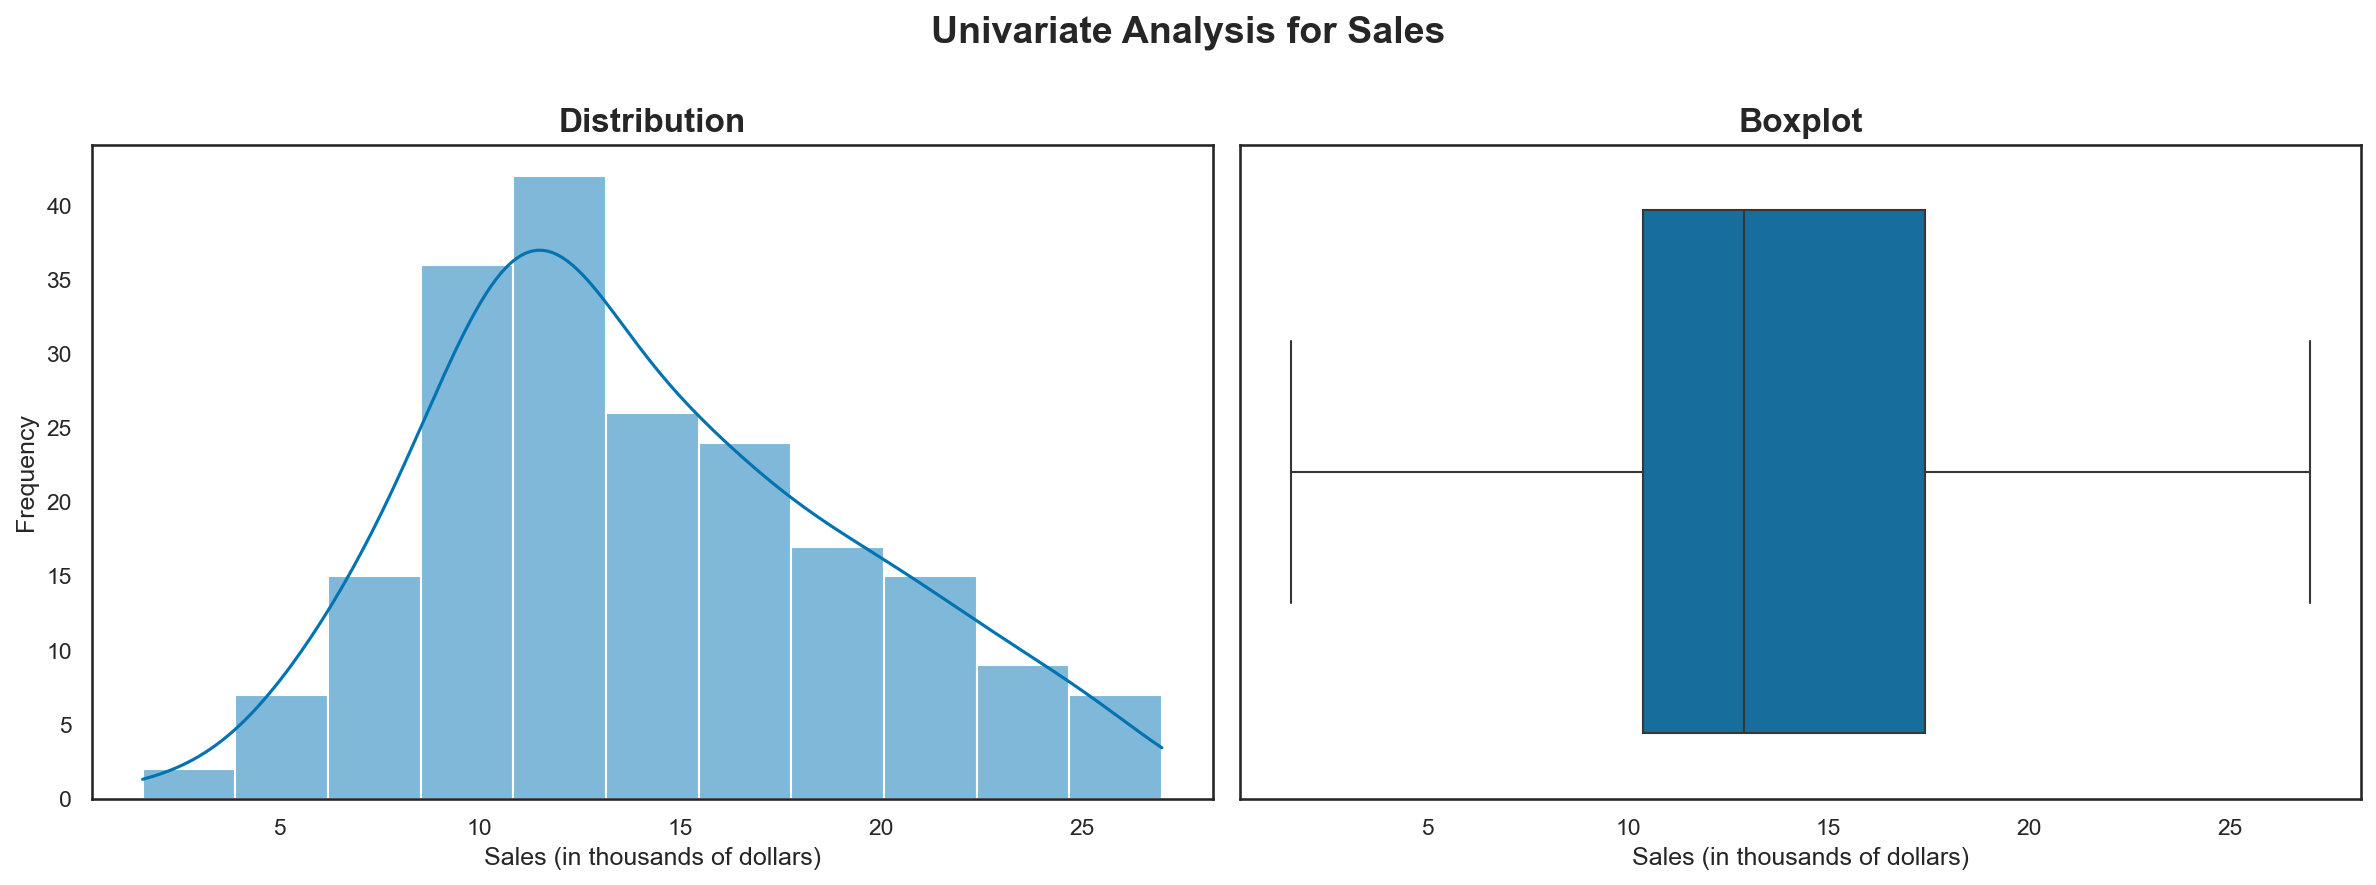

In [8]:
# Univariate Analysis for Sales
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for Sales", fontsize=18, fontweight='bold')

# The histogram of Sales
sns.histplot(sales_df, x="sales", kde=True, ax=ax[0])
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Sales (in thousands of dollars)")
ax[0].set_ylabel("Frequency")

# The boxplot of Sales
sns.boxplot(sales_df, x="sales", ax=ax[1])
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Sales (in thousands of dollars)")

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

### 5.4. Bivariate Analysis
Now it's time to analyze the relationship between our independent variable (`tv`) and dependent variable (`sales`).

In [9]:
# The correlation matrix
print(sales_df.corr())

             tv     sales
tv     1.000000  0.782224
sales  0.782224  1.000000


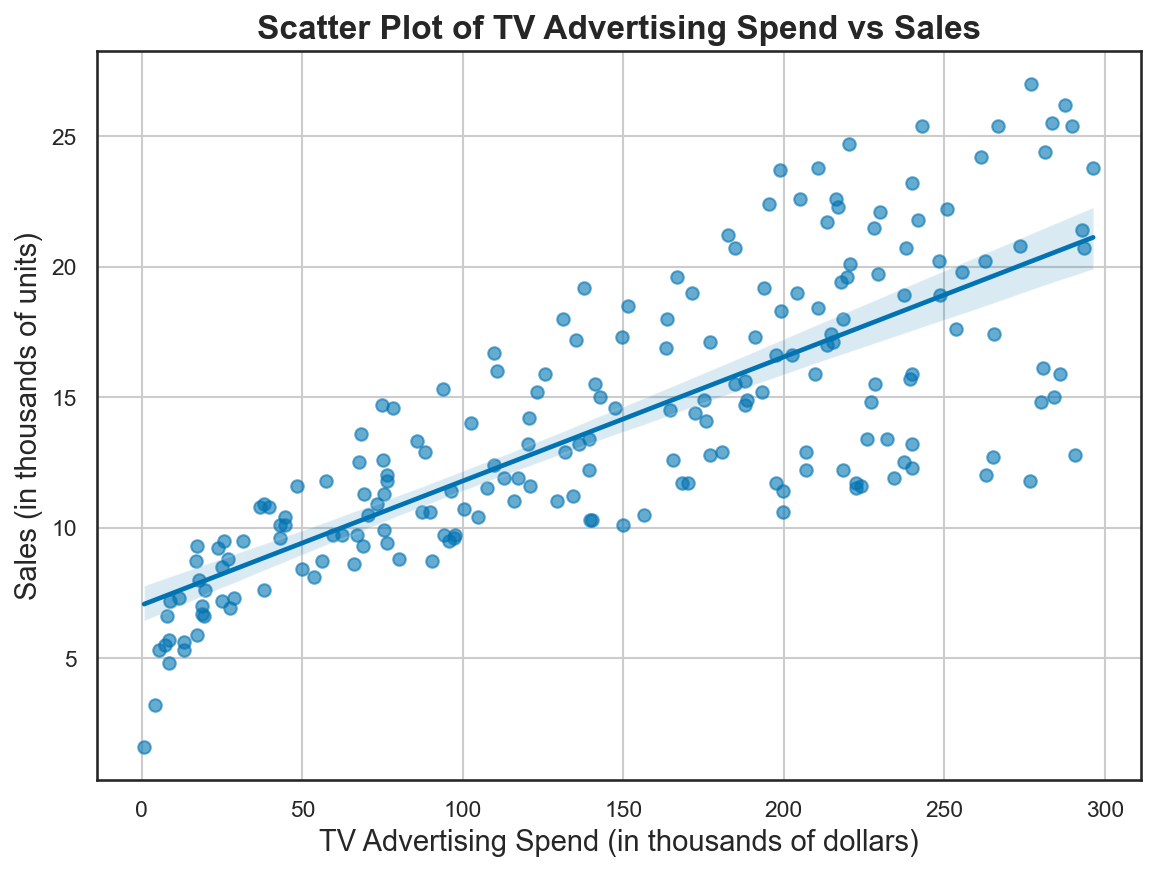

In [10]:
# The scatter plot
plt.figure()
sns.regplot(sales_df, x="tv", y="sales", scatter_kws={"alpha": 0.6})
plt.title("Scatter Plot of TV Advertising Spend vs Sales", fontsize=16, fontweight='bold')
plt.xlabel("TV Advertising Spend (in thousands of dollars)", fontsize=14)
plt.ylabel("Sales (in thousands of units)", fontsize=14)
plt.grid(True)
plt.show()

> #### 📝 Data Understanding Report (Summary)
> The data understanding stage confirms that the dataset is highly suitable for building a simple linear regression model. Both the independent variable (`tv`) and dependent variable (`sales`) have a wide range of values, which is ideal for modeling. The analysis revealed a strong positive correlation (0.78) between TV advertising spend and sales, validating our initial hypothesis.
> 
> While minor issues such as a slight right skew in the `sales` data were noted, they are not a significant concern for this type of analysis. The most critical finding is the presence of **heteroscedasticity**, where the model's prediction errors increase as TV ad spend grows.
> 
> Despite this, the fundamental linear relationship is strong enough to proceed with a simple linear regression model as an informative baseline. The discovery of heteroscedasticity provides a clear direction for future refinement, such as applying a log transformation to the `sales` variable to create a more robust and reliable model.

---

## Stage 6: Data Preparation
In this stage, we clean and prepare the data for modeling. This includes handling missing values, encoding categorical variables (if any), and scaling features as necessary. The goal is to ensure the dataset is in optimal condition for training our Simple Linear Regression model.

### 6.1. Data Cleaning

We've already confirmed that the data types of the columns are correct, and there are no outliers. Let's check if we have any missing values:

In [11]:
# Check for missing values
print("Number of missing values per column:")
print(sales_df.isnull().sum())

Number of missing values per column:
tv       0
sales    0
dtype: int64


### 6.2. Final Dataset Split
This project doesn't require feature engineering or data merging. Therefore our DataFrame is ready for the final split. 

In [12]:
# Feature and target variables
X = sales_df[["tv"]]
y = sales_df["sales"]

# Final train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

> #### 📝 Data Preparation Report (Summary)
> * No missing values or other data cleaning requirements were found in the dataset.
> * The dataset has been successfully split into training and testing sets, with 80% of the data allocated for training and 20% for testing.
> * The feature variable (`tv`) and target variable (`sales`) are correctly defined for modeling.

---

## Stage 7: Modeling
The goal of this stage is to build, train, and tune the candidate models identified in the Analytic Approach Stage. Using the prepared dataset from the previous stage, we will build and train our Simple Linear Regression model - which is the only candidate model for this lab project.

In [13]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


> #### 📝 Modeling Report (Summary)
> * A Simple Linear Regression model was successfully trained on the dataset using a standard 80/20 train-test split for validation.
> * For the scope of this foundational lab, more advanced techniques like k-fold cross-validation were not implemented. It is noted that this would be a standard next step for a more robust evaluation to ensure the model's performance is stable and generalizable.

---

## Stage 8: Evaluation
The goal of this stage is to rigorously evaluate the final "champion" model selected in Stage 7. We will use the held-back test set—data the model has never seen before—to obtain an unbiased estimate of its performance in the real world. The results will be compared against the project objectives and success criteria to make a final **go/no-go** decision for deployment.

### 8.1. Performance on the Hold-Out Test Set
Because we have not used cross-validation during training and also have not tried any other candidate models, we will skip the "final model training" step and evaluate the model on the hold-out test set to get an unbiased estimate of its performance.

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"R-squared on the test set: {r2:.4f}")

# Print the model coefficients
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for TV Advertising Spend: {model.coef_[0]:.4f}")

R-squared on the test set: 0.6767
Intercept: 7.1196
Coefficient for TV Advertising Spend: 0.0465


### 8.2. Business Impact Analysis
Now that we have the model's performance metrics, let's interpret them in the context of the original business problem and objectives defined in Stage 1.

> #### 📝 Evaluation Report (Summary)
> * The Simple Linear Regression model achieved an R-squared value of approximately 0.676 on the hold-out test set. This indicates that about 67.6% of the variance in sales can be explained by TV advertising spend alone, which is a strong result for a single-feature model.
> * The regression coefficient for TV advertising spend is approximately 0.047, meaning that for every additional thousand dollars spent on TV advertising, sales are expected to increase by about 47 units. This provides a clear, actionable insight for the marketing team.
> * 📌 **BUSINESS DECISION:** Even though the model meets the project goals by providing a quantifiable relationship between TV advertising and sales, there is still room for improvement. The R-squared value indicates a good fit, but addressing heteroscedasticity and potentially incorporating additional features in future iterations could enhance performance. Therefore, we recommend **not deploying** this initial model into production but rather using it as a foundation for further development and refinement.

---

**Next:** [Multiple Linear Regression Theory](./05_multiple_linear_regression_theory.md)